# Cálculo de velocidad orbital y oleaje desde ADV

Este notebook calcula las variables de oleaje directamente a partir de los datos del ADV (presión y velocidades), 
siguiendo la metodología de **Wiberg & Sherwood (2008)**.

**Métodos implementados:**
1. **Velocidad orbital representativa ($u_{br}$)** desde varianza de velocidades near-bed (Eq. 10)
2. **Velocidad orbital representativa ($u_{br}$)** desde espectro de velocidades near-bed (Eq. 11)
3. **Amplitud del oleaje local** desde espectro de presión con corrección de profundidad (Eq. 12)
4. **Período representativo del fondo ($T_{br}$)** desde espectro de velocidades (Eq. 9)

Finalmente se comparan los resultados con los valores pre-calculados en `orbital_velocity.xlsx`.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch

# Ruta base del pipeline
BASE_PATH = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..'))
print(f"BASE_PATH: {BASE_PATH}")

BASE_PATH: g:\Mi unidad\TFM_NoeliaGarciaGarcia\TFM_OxygenFlux\Pipeline


## Parámetros del instrumento y entorno

In [2]:
# Parámetros del ADV y del entorno
FS = 8                    # Frecuencia de muestreo (Hz)
WINDOW_MINUTES = 15       # Duración de cada ventana (minutos)
SAMPLES_PER_WINDOW = FS * 60 * WINDOW_MINUTES  # 7200 muestras
H = 15.0                  # Profundidad del agua (m)
Z_UV = 0.3                # Altura del sensor sobre el fondo (m) - ajustar si se conoce
G = 9.81                  # Aceleración gravitatoria (m/s²)
RHO = 1025.0              # Densidad del agua de mar (kg/m³)

# Rango de frecuencias válido para oleaje
F_MIN = 0.03              # Hz (período máximo ~33 s)
F_MAX = 0.5               # Hz (período mínimo 2 s)

print(f"Frecuencia muestreo: {FS} Hz")
print(f"Muestras por ventana: {SAMPLES_PER_WINDOW}")
print(f"Profundidad: {H} m")
print(f"Rango de frecuencias de oleaje: [{F_MIN}, {F_MAX}] Hz")

Frecuencia muestreo: 8 Hz
Muestras por ventana: 7200
Profundidad: 15.0 m
Rango de frecuencias de oleaje: [0.03, 0.5] Hz


## Funciones auxiliares: Teoría lineal de ondas

In [3]:
def qkhfs(omega, h):
    """
    Calcula kh (número de onda * profundidad) usando el método iterativo 
    de Newton-Raphson de Soulsby (2006). Implementación de Wiberg & Sherwood (2008), Appendix E.
    
    Parámetros:
        omega: frecuencia angular (rad/s) - array
        h: profundidad del agua (m) - escalar
    Retorna:
        kh: número de onda * profundidad (adimensional) - array
    """
    g = 9.81
    x = omega**2 * h / g
    y = np.where(x < 1, np.sqrt(x), x)
    
    # 3 iteraciones de Newton-Raphson (precisión ~3e-12)
    for _ in range(3):
        t = np.tanh(y)
        y = y - (y * t - x) / (t + y * (1 - t**2))
    
    return y


def wave_number(f, h):
    """
    Calcula el número de onda k para un array de frecuencias f y profundidad h.
    
    Parámetros:
        f: frecuencias (Hz) - array
        h: profundidad (m) - escalar
    Retorna:
        k: número de onda (rad/m) - array
    """
    omega = 2 * np.pi * f
    kh = qkhfs(omega, h)
    return kh / h


# Test: para T=10s, h=15m
f_test = 1/10  # 0.1 Hz
k_test = wave_number(np.array([f_test]), H)
L_test = 2 * np.pi / k_test[0]
print(f"Test: T=10s, h={H}m -> k={k_test[0]:.4f} rad/m, L={L_test:.1f} m")
print(f"  h/L = {H/L_test:.3f} (intermediate water si 0.05 < h/L < 0.5)")

Test: T=10s, h=15.0m -> k=0.0576 rad/m, L=109.0 m
  h/L = 0.138 (intermediate water si 0.05 < h/L < 0.5)


## Carga de datos crudos (df_master)

In [4]:
# Cargar df_master.csv
df_master_path = os.path.join(BASE_PATH, "DATA", "RAW", "df_master.csv")
print(f"Cargando {df_master_path}...")
df_master = pd.read_csv(df_master_path)
print(f"Shape: {df_master.shape}")
print(f"Columnas: {list(df_master.columns)}")
df_master.head()

Cargando g:\Mi unidad\TFM_NoeliaGarciaGarcia\TFM_OxygenFlux\Pipeline\DATA\RAW\df_master.csv...
Shape: (4971152, 7)
Columnas: ['hour', 'vx', 'vy', 'vz', 'O2', 'pres', 'temp']


,hour,vx,vy,vz,O2,pres,temp
0,13.000026,-2.110,2.385,-0.00510,218.730,1475.35,14.8686
1,13.000061,-2.280,2.515,-0.00540,218.835,1475.35,14.8692
2,13.000095,-2.990,2.710,-0.00685,218.597,1475.35,14.8692
3,13.000130,-2.945,2.895,-0.00685,218.746,1477.60,14.8692
4,13.000165,-3.045,2.745,-0.00560,218.348,1473.05,14.8692


In [5]:
# Convertir vx y vy de cm/s a m/s (vz ya está en m/s)
df_master['vx_ms'] = df_master['vx'] * 0.01  # cm/s -> m/s
df_master['vy_ms'] = df_master['vy'] * 0.01  # cm/s -> m/s

# Asignar window_id (igual que en notebook 1)
n_windows = len(df_master) // SAMPLES_PER_WINDOW
df_calc = df_master.iloc[:n_windows * SAMPLES_PER_WINDOW].copy()
df_calc['window_id'] = np.repeat(np.arange(n_windows), SAMPLES_PER_WINDOW)

print(f"Total ventanas: {n_windows}")
print(f"Muestras usadas: {len(df_calc)} de {len(df_master)}")

Total ventanas: 690
Muestras usadas: 4968000 de 4971152


## Método 1: $u_{br}$ desde varianza de velocidades (Eq. 10)

$$u_{br} = \sqrt{2(\text{var}(u') + \text{var}(v'))}$$

donde $u' = v_x - \overline{v_x}$ y $v' = v_y - \overline{v_y}$ son las componentes de velocidad con la media removida.

In [6]:
def calc_ubr_variance(group):
    """
    Calcula ubr usando Eq. 10 de Wiberg & Sherwood (2008).
    ubr = sqrt(2 * (var(u') + var(v')))
    """
    vx = group['vx_ms'].values
    vy = group['vy_ms'].values
    
    # Remover media (fluctuaciones)
    vx_prime = vx - np.mean(vx)
    vy_prime = vy - np.mean(vy)
    
    # Varianza de las fluctuaciones
    var_vx = np.var(vx_prime)
    var_vy = np.var(vy_prime)
    
    ubr = np.sqrt(2 * (var_vx + var_vy))
    return ubr


# Calcular por ventana
print("Calculando ubr por varianza (Eq. 10)...")
ubr_var = df_calc.groupby('window_id').apply(calc_ubr_variance)
ubr_var.name = 'ubr_variance'
print(f"Calculado para {len(ubr_var)} ventanas")
print(f"  ubr medio: {ubr_var.mean():.4f} m/s")
print(f"  ubr máx:   {ubr_var.max():.4f} m/s")

Calculando ubr por varianza (Eq. 10)...
Calculado para 690 ventanas
  ubr medio: 0.0722 m/s
  ubr máx:   0.1962 m/s


C:\Users\noeli\AppData\Local\Temp\ipykernel_7268\3653794576.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ubr_var = df_calc.groupby('window_id').apply(calc_ubr_variance)


## Método 2: $u_{br}$ desde espectro de velocidades (Eq. 11)

$$u_{br} = \sqrt{2 \sum_i S_{uv,i} \Delta f_i}$$

donde $S_{uv} = S_{uu} + S_{vv}$ es el espectro combinado horizontal, integrado solo en el rango de frecuencias del oleaje.

También se calcula el **período representativo del fondo** (Eq. 9):
$$f_{br} = \frac{\sum_i f_i S_{uv,i} \Delta f_i}{\sum_i S_{uv,i} \Delta f_i}$$

In [7]:
def calc_ubr_spectral(group):
    """
    Calcula ubr y Tbr desde espectros de velocidad near-bed.
    Wiberg & Sherwood (2008), Eqs. 11 y 9.
    
    Retorna: ubr (m/s), Tbr (s), Hs_local (m)
    """
    vx = group['vx_ms'].values
    vy = group['vy_ms'].values
    pres_mbar = group['pres'].values
    
    # Remover media
    vx_prime = vx - np.mean(vx)
    vy_prime = vy - np.mean(vy)
    
    # Calcular espectros con método de Welch
    # nperseg = 1024 da resolución de ~0.0078 Hz con 8 Hz de muestreo
    nperseg = min(1024, len(vx_prime) // 4)
    
    f, Suu = welch(vx_prime, fs=FS, nperseg=nperseg, noverlap=nperseg//2)
    f, Svv = welch(vy_prime, fs=FS, nperseg=nperseg, noverlap=nperseg//2)
    
    # Espectro combinado horizontal
    Suv = Suu + Svv
    
    # Filtrar al rango de frecuencias de oleaje
    mask = (f >= F_MIN) & (f <= F_MAX)
    f_wave = f[mask]
    Suv_wave = Suv[mask]
    
    if len(f_wave) == 0 or np.sum(Suv_wave) == 0:
        return pd.Series({'ubr_spectral': 0, 'Tbr': np.nan, 'Hs_local': 0, 'std_orbital': 0})
    
    # Ancho de banda
    df_freq = f_wave[1] - f_wave[0] if len(f_wave) > 1 else 1.0
    
    # ubr = sqrt(2 * sum(Suv * df))  (Eq. 11)
    ubr = np.sqrt(2 * np.sum(Suv_wave * df_freq))
    
    # Frecuencia representativa del fondo (Eq. 9)
    fbr = np.sum(f_wave * Suv_wave * df_freq) / np.sum(Suv_wave * df_freq)
    Tbr = 1.0 / fbr if fbr > 0 else np.nan
    
    # Desviación estándar de velocidad orbital
    std_orbital = np.sqrt(np.sum(Suv_wave * df_freq))
    
    # Hs local desde presión (Eq. 12 adaptada)
    # Convertir presión de mbar a metros de columna de agua
    pres_m = (pres_mbar - np.mean(pres_mbar)) / (RHO * G / 100)  # mbar -> m
    f_p, Spp = welch(pres_m, fs=FS, nperseg=nperseg, noverlap=nperseg//2)
    
    mask_p = (f_p >= F_MIN) & (f_p <= F_MAX)
    f_p_wave = f_p[mask_p]
    Spp_wave = Spp[mask_p]
    
    # Corrección por atenuación de presión con la profundidad
    # Factor de transferencia: cosh(k*z_sensor) / cosh(k*h)
    # Para sensor en el fondo (z≈0): factor = 1/cosh(kh)
    k_wave = wave_number(f_p_wave, H)
    kh_wave = k_wave * H
    
    # Factor de corrección de presión (sensor en el fondo)
    # Kp = cosh(k*(h-z_sensor)) / cosh(kh) ≈ 1/cosh(kh) para z_sensor ≈ 0
    Kp = np.cosh(k_wave * Z_UV) / np.cosh(kh_wave)
    Kp = np.maximum(Kp, 0.1)  # Evitar amplificaciones extremas
    
    # Espectro de elevación de superficie desde presión
    S_eta = Spp_wave / (Kp**2)
    
    # Hs = 4 * sqrt(m0)
    m0 = np.sum(S_eta * df_freq)
    Hs_local = 4 * np.sqrt(m0) if m0 > 0 else 0
    
    return pd.Series({
        'ubr_spectral': ubr,
        'Tbr': Tbr,
        'Hs_local': Hs_local,
        'std_orbital': std_orbital
    })


# Calcular por ventana
print("Calculando ubr espectral, Tbr y Hs local (esto puede tardar unos minutos)...")
results_spectral = df_calc.groupby('window_id').apply(calc_ubr_spectral)
print(f"Calculado para {len(results_spectral)} ventanas")
print(f"\nResumen:")
print(results_spectral.describe())

Calculando ubr espectral, Tbr y Hs local (esto puede tardar unos minutos)...
Calculado para 690 ventanas

Resumen:
       ubr_spectral         Tbr    Hs_local  std_orbital
count    690.000000  690.000000  690.000000   690.000000
mean       0.067304    8.906897    0.412707     0.047591
std        0.032472    1.211313    0.166583     0.022961
min        0.014336    3.585657    0.066375     0.010137
25%        0.031130    8.589143    0.214241     0.022012
50%        0.068395    9.081848    0.431214     0.048362
75%        0.091630    9.666523    0.537232     0.064792
max        0.146419   10.990517    1.086877     0.103534


C:\Users\noeli\AppData\Local\Temp\ipykernel_7268\1422643187.py:84: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  results_spectral = df_calc.groupby('window_id').apply(calc_ubr_spectral)


## Compilar resultados por ventana

In [8]:
# Calcular hora media por ventana (para merge con orbital_velocity.xlsx)
hour_mean = df_calc.groupby('window_id')['hour'].mean()

# Compilar todos los resultados
df_results = pd.DataFrame({
    'window_id': np.arange(n_windows),
    'hour': hour_mean.values,
    'ubr_variance': ubr_var.values,
    'ubr_spectral': results_spectral['ubr_spectral'].values,
    'Tbr': results_spectral['Tbr'].values,
    'Hs_local': results_spectral['Hs_local'].values,
    'std_orbital': results_spectral['std_orbital'].values,
})

# ubs (significant bottom orbital velocity) = sqrt(2) * ubr
df_results['ubs_variance'] = np.sqrt(2) * df_results['ubr_variance']
df_results['ubs_spectral'] = np.sqrt(2) * df_results['ubr_spectral']

print("Resultados compilados:")
df_results.head(10)

Resultados compilados:


,window_id,hour,ubr_variance,ubr_spectral,Tbr,Hs_local,std_orbital,ubs_variance,ubs_spectral
0,0,13.125009,0.031129,0.026769,9.202945,0.206076,0.018929,0.044023,0.037857
1,1,13.375009,0.034132,0.029209,9.174509,0.198842,0.020654,0.048270,0.041308
2,2,13.625009,0.027339,0.024024,8.841617,0.179626,0.016988,0.038664,0.033975
3,3,13.875009,0.025489,0.022793,9.078351,0.184669,0.016117,0.036047,0.032234
4,4,14.125009,0.027697,0.023513,8.896689,0.200980,0.016626,0.039169,0.033253
5,5,14.375009,0.028319,0.026634,9.171962,0.203298,0.018833,0.040048,0.037666
6,6,14.625009,0.024109,0.022012,8.532577,0.187352,0.015565,0.034096,0.031129
7,7,14.875009,0.027752,0.025882,9.058452,0.207772,0.018301,0.039247,0.036602
8,8,15.125009,0.028233,0.024745,8.848146,0.200556,0.017498,0.039927,0.034995
9,9,15.375009,0.029936,0.029538,9.081593,0.213869,0.020887,0.042337,0.041774


## Carga de datos de referencia (`orbital_velocity.xlsx`)

In [9]:
# Cargar orbital_velocity.xlsx (datos pre-calculados)
orb_path = os.path.join(BASE_PATH, "DATA", "MASTER", "orbital_velocity.xlsx")
df_orb = pd.read_excel(orb_path, header=1)
print(f"Columnas orbital_velocity.xlsx: {list(df_orb.columns)}")
print(f"Shape: {df_orb.shape}")
df_orb.head()

Columnas orbital_velocity.xlsx: ['Time Mean', 'Flux 2', 'O2mean', 'vMean', 'SDpress2', 'Oleaje', 'Mod_orbital', 'STD_orbital']
Shape: (668, 8)


,Time Mean,Flux 2,O2mean,vMean,SDpress2,Oleaje,Mod_orbital,STD_orbital
0,13.12,-12.577,219.341,3.865,2.416,9.664,0.015203,0.009969
1,13.37,-14.769,220.213,4.993,2.469,9.876,0.015946,0.010475
2,13.62,-6.191,220.538,4.823,2.251,9.004,0.013689,0.008438
3,13.87,-4.962,220.398,4.305,2.139,8.556,0.012808,0.008059
4,14.12,-11.998,220.429,3.628,2.375,9.500,0.013456,0.007926


In [10]:
# Renombrar columna de tiempo para merge
df_orb.rename(columns={'Time Mean': 'hour'}, inplace=True)

# Redondear horas para merge
df_results['hour_round'] = np.round(df_results['hour'], 2)
df_orb['hour_round'] = np.round(df_orb['hour'], 2)

# Merge por hora (tolerancia)
df_compare = pd.merge_asof(
    df_results.sort_values('hour'),
    df_orb[['hour_round', 'Oleaje', 'Mod_orbital', 'STD_orbital']].sort_values('hour_round'),
    left_on='hour',
    right_on='hour_round',
    tolerance=0.05,  # tolerancia de ~3 minutos
    direction='nearest',
    suffixes=('', '_ref')
)

print(f"\nVentanas emparejadas: {df_compare['Mod_orbital'].notna().sum()} de {len(df_compare)}")
df_compare.head()


Ventanas emparejadas: 668 de 690


,window_id,hour,ubr_variance,ubr_spectral,Tbr,Hs_local,std_orbital,ubs_variance,ubs_spectral,hour_round,hour_round_ref,Oleaje,Mod_orbital,STD_orbital
0,0,13.125009,0.031129,0.026769,9.202945,0.206076,0.018929,0.044023,0.037857,13.13,13.12,9.664,0.015203,0.009969
1,1,13.375009,0.034132,0.029209,9.174509,0.198842,0.020654,0.048270,0.041308,13.38,13.37,9.876,0.015946,0.010475
2,2,13.625009,0.027339,0.024024,8.841617,0.179626,0.016988,0.038664,0.033975,13.63,13.62,9.004,0.013689,0.008438
3,3,13.875009,0.025489,0.022793,9.078351,0.184669,0.016117,0.036047,0.032234,13.88,13.87,8.556,0.012808,0.008059
4,4,14.125009,0.027697,0.023513,8.896689,0.200980,0.016626,0.039169,0.033253,14.13,14.12,9.500,0.013456,0.007926


## Comparación: ubr calculado vs Mod_orbital (referencia)

Ventanas válidas para comparación: 668


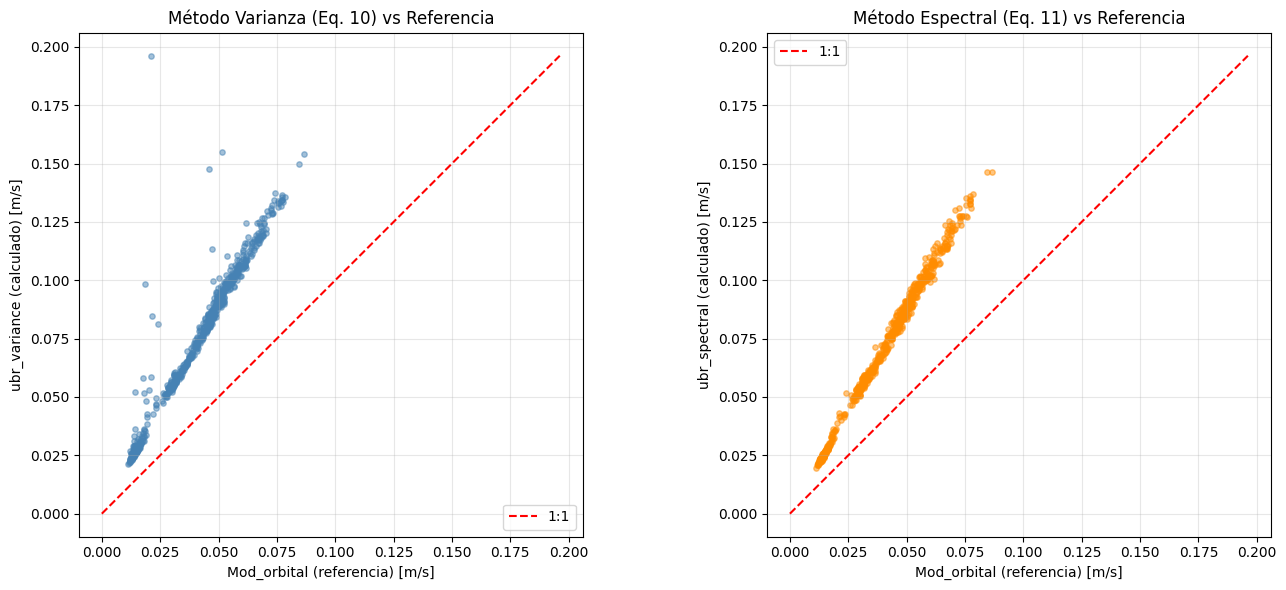

In [11]:
# Filtrar filas con datos de referencia válidos
mask_valid = df_compare['Mod_orbital'].notna() & (df_compare['Mod_orbital'] > 0)
df_valid = df_compare[mask_valid].copy()

print(f"Ventanas válidas para comparación: {len(df_valid)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter ubr_variance vs Mod_orbital
ax = axes[0]
ax.scatter(df_valid['Mod_orbital'], df_valid['ubr_variance'], 
           alpha=0.5, s=15, c='steelblue')
max_val = max(df_valid['Mod_orbital'].max(), df_valid['ubr_variance'].max())
ax.plot([0, max_val], [0, max_val], 'r--', lw=1.5, label='1:1')
ax.set_xlabel('Mod_orbital (referencia) [m/s]')
ax.set_ylabel('ubr_variance (calculado) [m/s]')
ax.set_title('Método Varianza (Eq. 10) vs Referencia')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

# Scatter ubr_spectral vs Mod_orbital
ax = axes[1]
ax.scatter(df_valid['Mod_orbital'], df_valid['ubr_spectral'], 
           alpha=0.5, s=15, c='darkorange')
ax.plot([0, max_val], [0, max_val], 'r--', lw=1.5, label='1:1')
ax.set_xlabel('Mod_orbital (referencia) [m/s]')
ax.set_ylabel('ubr_spectral (calculado) [m/s]')
ax.set_title('Método Espectral (Eq. 11) vs Referencia')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

## Comparación: Hs local (presión) vs Oleaje (referencia)

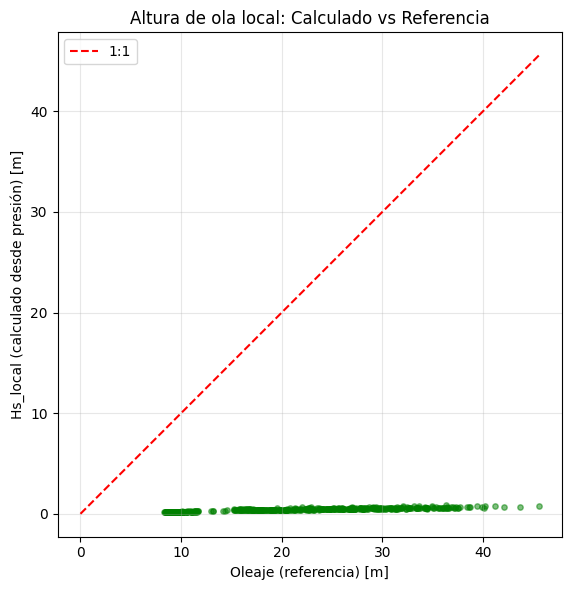

In [12]:
mask_oleaje = df_compare['Oleaje'].notna() & (df_compare['Oleaje'] > 0)
df_oleaje_valid = df_compare[mask_oleaje].copy()

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(df_oleaje_valid['Oleaje'], df_oleaje_valid['Hs_local'], 
           alpha=0.5, s=15, c='green')
max_val_h = max(df_oleaje_valid['Oleaje'].max(), df_oleaje_valid['Hs_local'].max())
ax.plot([0, max_val_h], [0, max_val_h], 'r--', lw=1.5, label='1:1')
ax.set_xlabel('Oleaje (referencia) [m]')
ax.set_ylabel('Hs_local (calculado desde presión) [m]')
ax.set_title('Altura de ola local: Calculado vs Referencia')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## Series temporales comparadas

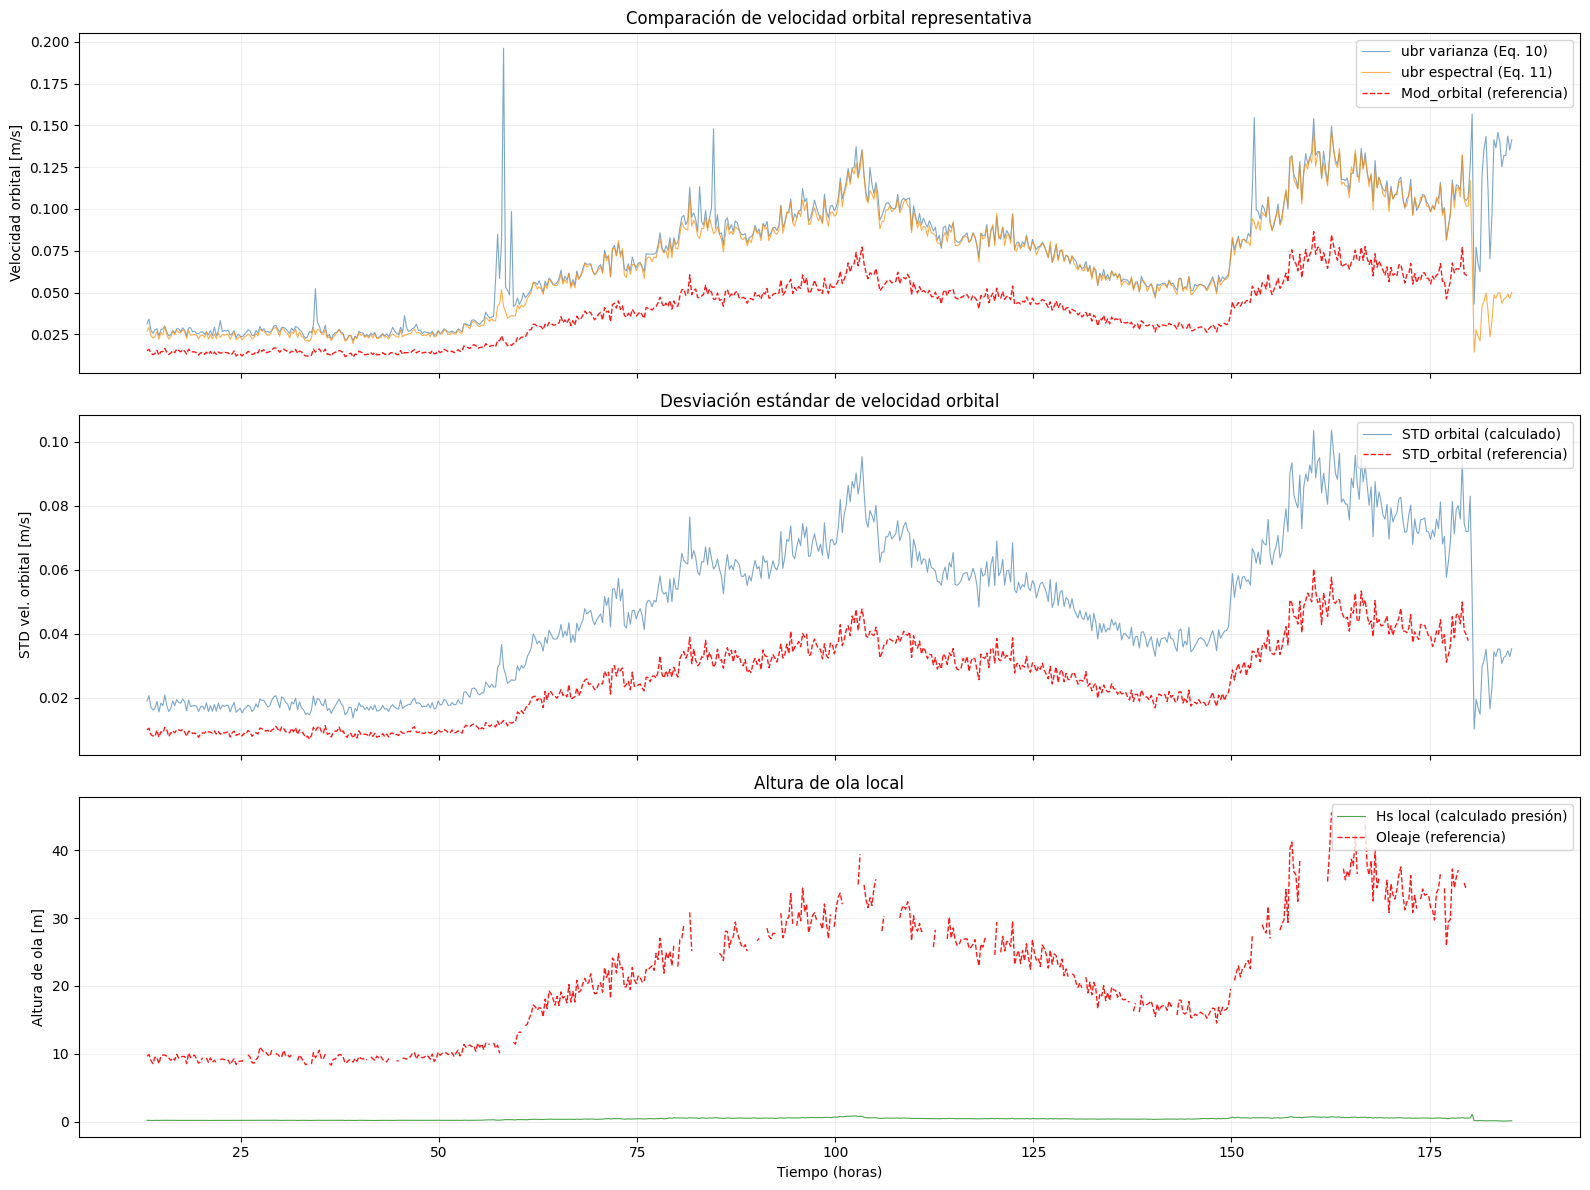

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

# Panel 1: Velocidad orbital
ax = axes[0]
ax.plot(df_compare['hour'], df_compare['ubr_variance'], 
        alpha=0.7, lw=0.8, label='ubr varianza (Eq. 10)', color='steelblue')
ax.plot(df_compare['hour'], df_compare['ubr_spectral'], 
        alpha=0.7, lw=0.8, label='ubr espectral (Eq. 11)', color='darkorange')
ax.plot(df_compare['hour'], df_compare['Mod_orbital'], 
        alpha=0.9, lw=1.0, label='Mod_orbital (referencia)', color='red', linestyle='--')
ax.set_ylabel('Velocidad orbital [m/s]')
ax.set_title('Comparación de velocidad orbital representativa')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.2)

# Panel 2: Desviación estándar orbital
ax = axes[1]
ax.plot(df_compare['hour'], df_compare['std_orbital'], 
        alpha=0.7, lw=0.8, label='STD orbital (calculado)', color='steelblue')
ax.plot(df_compare['hour'], df_compare['STD_orbital'], 
        alpha=0.9, lw=1.0, label='STD_orbital (referencia)', color='red', linestyle='--')
ax.set_ylabel('STD vel. orbital [m/s]')
ax.set_title('Desviación estándar de velocidad orbital')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.2)

# Panel 3: Altura de ola
ax = axes[2]
ax.plot(df_compare['hour'], df_compare['Hs_local'], 
        alpha=0.7, lw=0.8, label='Hs local (calculado presión)', color='green')
ax.plot(df_compare['hour'], df_compare['Oleaje'], 
        alpha=0.9, lw=1.0, label='Oleaje (referencia)', color='red', linestyle='--')
ax.set_xlabel('Tiempo (horas)')
ax.set_ylabel('Altura de ola [m]')
ax.set_title('Altura de ola local')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

## Métricas de acuerdo

In [14]:
def brier_skill_score(observed, predicted):
    """
    Brier Skill Score (BSS) - Wiberg & Sherwood (2008), Table 2.
    BSS = 1 - sum((obs - pred)²) / sum((obs - mean(obs))²)
    BSS > 0: mejor que la media; BSS = 1: perfecto.
    """
    mask = np.isfinite(observed) & np.isfinite(predicted)
    obs = observed[mask]
    pred = predicted[mask]
    if len(obs) == 0:
        return np.nan
    ss_res = np.sum((obs - pred)**2)
    ss_tot = np.sum((obs - np.mean(obs))**2)
    if ss_tot == 0:
        return np.nan
    return 1 - ss_res / ss_tot


def rmse(observed, predicted):
    mask = np.isfinite(observed) & np.isfinite(predicted)
    return np.sqrt(np.mean((observed[mask] - predicted[mask])**2))


def correlation(observed, predicted):
    mask = np.isfinite(observed) & np.isfinite(predicted)
    return np.corrcoef(observed[mask], predicted[mask])[0, 1]


# Métricas para ubr
print("=" * 60)
print("MÉTRICAS DE ACUERDO: ubr calculado vs Mod_orbital (ref)")
print("=" * 60)

obs = df_valid['Mod_orbital'].values

for method, col in [('Varianza (Eq. 10)', 'ubr_variance'), 
                     ('Espectral (Eq. 11)', 'ubr_spectral')]:
    pred = df_valid[col].values
    print(f"\n{method}:")
    print(f"  BSS  = {brier_skill_score(obs, pred):.3f}")
    print(f"  RMSE = {rmse(obs, pred):.4f} m/s")
    print(f"  r    = {correlation(obs, pred):.3f}")
    print(f"  Ratio medio (calc/ref) = {np.mean(pred/obs[obs>0]):.3f}")

# Métricas para oleaje
print(f"\n{'=' * 60}")
print("MÉTRICAS DE ACUERDO: Hs_local vs Oleaje (ref)")
print("=" * 60)
obs_h = df_oleaje_valid['Oleaje'].values
pred_h = df_oleaje_valid['Hs_local'].values
print(f"  BSS  = {brier_skill_score(obs_h, pred_h):.3f}")
print(f"  RMSE = {rmse(obs_h, pred_h):.4f} m")
print(f"  r    = {correlation(obs_h, pred_h):.3f}")

MÉTRICAS DE ACUERDO: ubr calculado vs Mod_orbital (ref)

Varianza (Eq. 10):
  BSS  = -2.727
  RMSE = 0.0359 m/s
  r    = 0.968
  Ratio medio (calc/ref) = 1.865

Espectral (Eq. 11):
  BSS  = -2.079
  RMSE = 0.0326 m/s
  r    = 0.998
  Ratio medio (calc/ref) = 1.767

MÉTRICAS DE ACUERDO: Hs_local vs Oleaje (ref)
  BSS  = -4.813
  RMSE = 21.9911 m
  r    = 0.942


## Análisis de diferencias

Si los valores no coinciden perfectamente, las posibles razones son:
- Diferente rango de frecuencias usado para filtrar oleaje
- Diferente método de cálculo del espectro (Welch vs FFT directa)
- Diferente definición de ventana temporal
- Conversión de unidades de presión
- Valor de profundidad `h` o altura del sensor `z_uv` diferente

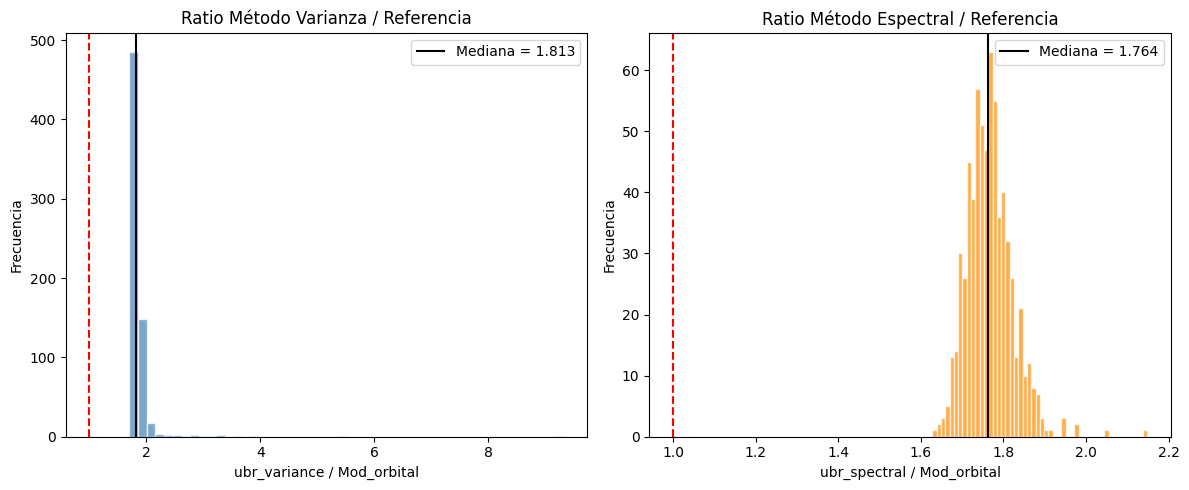


Si la mediana del ratio es ~sqrt(2) ≈ 1.414, 
la referencia probablemente usa ubs en vez de ubr (o viceversa).


In [15]:
# Histograma de ratios
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Ratio ubr_variance / Mod_orbital
ax = axes[0]
ratio_var = df_valid['ubr_variance'] / df_valid['Mod_orbital']
ax.hist(ratio_var, bins=50, alpha=0.7, color='steelblue', edgecolor='white')
ax.axvline(1.0, color='red', linestyle='--', lw=1.5)
ax.axvline(ratio_var.median(), color='black', linestyle='-', lw=1.5, 
           label=f'Mediana = {ratio_var.median():.3f}')
ax.set_xlabel('ubr_variance / Mod_orbital')
ax.set_ylabel('Frecuencia')
ax.set_title('Ratio Método Varianza / Referencia')
ax.legend()

# Ratio ubr_spectral / Mod_orbital
ax = axes[1]
ratio_spec = df_valid['ubr_spectral'] / df_valid['Mod_orbital']
ax.hist(ratio_spec, bins=50, alpha=0.7, color='darkorange', edgecolor='white')
ax.axvline(1.0, color='red', linestyle='--', lw=1.5)
ax.axvline(ratio_spec.median(), color='black', linestyle='-', lw=1.5,
           label=f'Mediana = {ratio_spec.median():.3f}')
ax.set_xlabel('ubr_spectral / Mod_orbital')
ax.set_ylabel('Frecuencia')
ax.set_title('Ratio Método Espectral / Referencia')
ax.legend()

plt.tight_layout()
plt.show()

print(f"\nSi la mediana del ratio es ~sqrt(2) ≈ {np.sqrt(2):.3f}, ")
print(f"la referencia probablemente usa ubs en vez de ubr (o viceversa).")

## Espectro ejemplo de una ventana con oleaje

Ventana con mayor ubr: window_id=598, ubr=0.1464 m/s


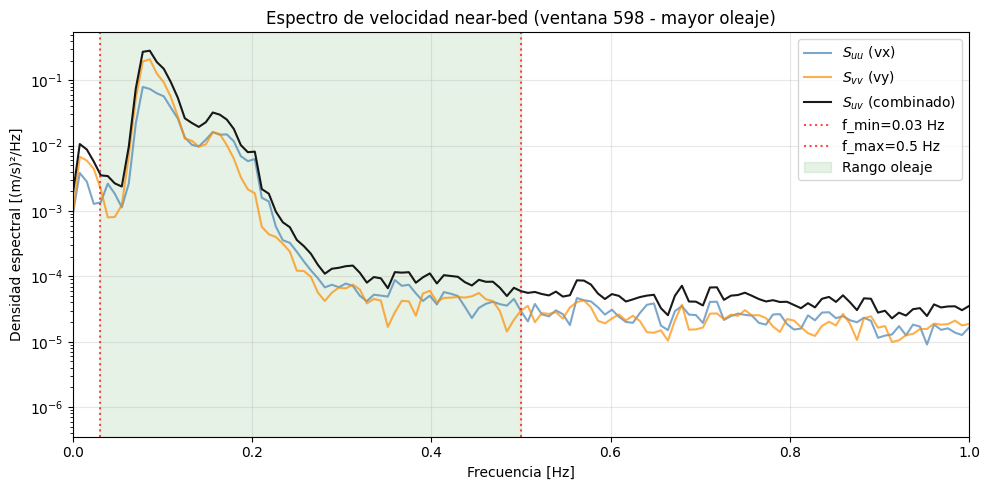

In [16]:
# Seleccionar ventana con mayor velocidad orbital
idx_max = df_results['ubr_spectral'].idxmax()
win_id = df_results.loc[idx_max, 'window_id']
print(f"Ventana con mayor ubr: window_id={win_id}, ubr={df_results.loc[idx_max, 'ubr_spectral']:.4f} m/s")

# Extraer datos de esa ventana
win_data = df_calc[df_calc['window_id'] == win_id]
vx_win = (win_data['vx_ms'] - win_data['vx_ms'].mean()).values
vy_win = (win_data['vy_ms'] - win_data['vy_ms'].mean()).values

# Calcular espectros
nperseg = 1024
f_s, Suu_s = welch(vx_win, fs=FS, nperseg=nperseg, noverlap=nperseg//2)
_, Svv_s = welch(vy_win, fs=FS, nperseg=nperseg, noverlap=nperseg//2)
Suv_s = Suu_s + Svv_s

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogy(f_s, Suu_s, alpha=0.7, label='$S_{uu}$ (vx)', color='steelblue')
ax.semilogy(f_s, Svv_s, alpha=0.7, label='$S_{vv}$ (vy)', color='darkorange')
ax.semilogy(f_s, Suv_s, alpha=0.9, label='$S_{uv}$ (combinado)', color='black', lw=1.5)
ax.axvline(F_MIN, color='red', linestyle=':', alpha=0.7, label=f'f_min={F_MIN} Hz')
ax.axvline(F_MAX, color='red', linestyle=':', alpha=0.7, label=f'f_max={F_MAX} Hz')
ax.axvspan(F_MIN, F_MAX, alpha=0.1, color='green', label='Rango oleaje')
ax.set_xlabel('Frecuencia [Hz]')
ax.set_ylabel('Densidad espectral [(m/s)²/Hz]')
ax.set_title(f'Espectro de velocidad near-bed (ventana {win_id} - mayor oleaje)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
plt.tight_layout()
plt.show()

## Guardar resultados

In [17]:
# Guardar resultados calculados
output_path = os.path.join(BASE_PATH, "DATA", "PROCESSED", "df_wave_adv.csv")
df_results.to_csv(output_path, index=False)
print(f"Resultados guardados en: {output_path}")
print(f"Columnas: {list(df_results.columns)}")

Resultados guardados en: g:\Mi unidad\TFM_NoeliaGarciaGarcia\TFM_OxygenFlux\Pipeline\DATA\PROCESSED\df_wave_adv.csv
Columnas: ['window_id', 'hour', 'ubr_variance', 'ubr_spectral', 'Tbr', 'Hs_local', 'std_orbital', 'ubs_variance', 'ubs_spectral', 'hour_round']
